In [1]:
print('hello')

hello


In [2]:
# ============================================================
# Block 1: Imports + Project Setup
# LOCAL VERSION WITH DELTA SUPPORT
# ============================================================

import os
import sys
import json
import time
import shutil
import pandas as pd

from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.sql.window import Window

from delta import configure_spark_with_delta_pip

# ------------------------------------------------------------
# Create / get Spark session with Delta Lake support
# ------------------------------------------------------------
builder = SparkSession.builder \
    .appName("DS2002 Final Project - Streaming Lakehouse") \
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension") \
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog")

spark = configure_spark_with_delta_pip(builder).getOrCreate()

# ------------------------------------------------------------
# Project/database names
# ------------------------------------------------------------
database_name = "olist_final_project"

spark.sql(f"CREATE DATABASE IF NOT EXISTS {database_name}")
spark.sql(f"USE {database_name}")

# ------------------------------------------------------------
# Base paths
# Local version: your actual final project folder
# ------------------------------------------------------------
base_path = r"C:\uva\spr2026\DS2002\final"

bronze_path = os.path.join(base_path, "bronze")
silver_path = os.path.join(base_path, "silver")
gold_path = os.path.join(base_path, "gold")
checkpoint_path = os.path.join(base_path, "checkpoints")

source_path = base_path

orders_source_path = os.path.join(source_path, "olist_orders_dataset.csv")
order_items_source_path = os.path.join(source_path, "olist_order_items_dataset.csv")
customers_source_path = os.path.join(source_path, "olist_customers_dataset.csv")
products_source_path = os.path.join(source_path, "olist_products_dataset.csv")
payments_source_path = os.path.join(source_path, "olist_order_payments_dataset.csv")

streaming_orders_path = os.path.join(source_path, "streaming_orders")

# ------------------------------------------------------------
# Create folders locally
# ------------------------------------------------------------
os.makedirs(bronze_path, exist_ok=True)
os.makedirs(silver_path, exist_ok=True)
os.makedirs(gold_path, exist_ok=True)
os.makedirs(checkpoint_path, exist_ok=True)
os.makedirs(streaming_orders_path, exist_ok=True)

print("Project setup complete.")
print(f"Using database: {database_name}")
print(f"Base path: {base_path}")
print(f"Source path: {source_path}")

Project setup complete.
Using database: olist_final_project
Base path: C:\uva\spr2026\DS2002\final
Source path: C:\uva\spr2026\DS2002\final


In [3]:
# ============================================================
# Check source files
# ============================================================

source_files = [
    orders_source_path,
    order_items_source_path,
    customers_source_path,
    products_source_path,
    payments_source_path
]

for file in source_files:
    print(file, "exists:", os.path.exists(file))

C:\uva\spr2026\DS2002\final\olist_orders_dataset.csv exists: True
C:\uva\spr2026\DS2002\final\olist_order_items_dataset.csv exists: True
C:\uva\spr2026\DS2002\final\olist_customers_dataset.csv exists: True
C:\uva\spr2026\DS2002\final\olist_products_dataset.csv exists: True
C:\uva\spr2026\DS2002\final\olist_order_payments_dataset.csv exists: True


In [5]:
# ============================================================
# Block 2: Load Source CSV Files
# ============================================================

# ------------------------------------------------------------
# Read source CSV files into Spark DataFrames
# ------------------------------------------------------------

df_orders = spark.read \
    .format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load(orders_source_path)

df_order_items = spark.read \
    .format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load(order_items_source_path)

df_customers = spark.read \
    .format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load(customers_source_path)

df_products = spark.read \
    .format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load(products_source_path)

df_payments = spark.read \
    .format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load(payments_source_path)

print("CSV files loaded successfully.")

CSV files loaded successfully.


In [6]:
# ============================================================
# Block 3: Write Raw Source Data to Bronze Delta Tables
# ============================================================

# ------------------------------------------------------------
# Define Bronze table paths
# ------------------------------------------------------------
bronze_orders_path = os.path.join(bronze_path, "orders")
bronze_order_items_path = os.path.join(bronze_path, "order_items")
bronze_customers_path = os.path.join(bronze_path, "customers")
bronze_products_path = os.path.join(bronze_path, "products")
bronze_payments_path = os.path.join(bronze_path, "payments")

# ------------------------------------------------------------
# Write raw DataFrames to Bronze Delta format
# ------------------------------------------------------------
df_orders.write \
    .format("delta") \
    .mode("overwrite") \
    .save(bronze_orders_path)

df_order_items.write \
    .format("delta") \
    .mode("overwrite") \
    .save(bronze_order_items_path)

df_customers.write \
    .format("delta") \
    .mode("overwrite") \
    .save(bronze_customers_path)

df_products.write \
    .format("delta") \
    .mode("overwrite") \
    .save(bronze_products_path)

df_payments.write \
    .format("delta") \
    .mode("overwrite") \
    .save(bronze_payments_path)

print("Bronze Delta tables written successfully.")

Bronze Delta tables written successfully.


Did Block 3 Run Correctly? 


In [7]:
# ============================================================
# Block 3 Check: Verify Bronze Delta Tables
# ============================================================

bronze_tables = {
    "orders": bronze_orders_path,
    "order_items": bronze_order_items_path,
    "customers": bronze_customers_path,
    "products": bronze_products_path,
    "payments": bronze_payments_path
}

for table_name, table_path in bronze_tables.items():
    print("=" * 70)
    print(f"Checking Bronze table: {table_name}")
    print(f"Path: {table_path}")
    
    # Check if folder exists
    print("Folder exists:", os.path.exists(table_path))
    
    # Check if Delta log exists
    delta_log_path = os.path.join(table_path, "_delta_log")
    print("Delta log exists:", os.path.exists(delta_log_path))
    
    # Try reading the Delta table
    try:
        df_check = spark.read.format("delta").load(table_path)
        print("Read status: SUCCESS")
        print("Row count:", df_check.count())
        print("Columns:", df_check.columns)
        df_check.show(5)
    except Exception as e:
        print("Read status: FAILED")
        print("Error:", e)

Checking Bronze table: orders
Path: C:\uva\spr2026\DS2002\final\bronze\orders
Folder exists: True
Delta log exists: True
Read status: SUCCESS
Row count: 99441
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
+--------------------+--------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|            order_id|         customer_id|order_status|order_purchase_timestamp|  order_approved_at|order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|
+--------------------+--------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|d9eabc69f974b3d08...|d4be0795e8fa7ea79...|   delivered|     2018-03

In [8]:
#BLOCK 4 


# ============================================================
# Block 4: Clean Bronze Data into Silver Dimension Tables
# ============================================================

# ------------------------------------------------------------
# Read Bronze Delta tables
# ------------------------------------------------------------
df_bronze_orders = spark.read.format("delta").load(bronze_orders_path)
df_bronze_order_items = spark.read.format("delta").load(bronze_order_items_path)
df_bronze_customers = spark.read.format("delta").load(bronze_customers_path)
df_bronze_products = spark.read.format("delta").load(bronze_products_path)
df_bronze_payments = spark.read.format("delta").load(bronze_payments_path)

# ------------------------------------------------------------
# Clean customer dimension
# ------------------------------------------------------------
df_dim_customers = df_bronze_customers \
    .select(
        col("customer_id"),
        col("customer_unique_id"),
        col("customer_zip_code_prefix").cast("int").alias("customer_zip_code_prefix"),
        lower(trim(col("customer_city"))).alias("customer_city"),
        upper(trim(col("customer_state"))).alias("customer_state")
    ) \
    .dropDuplicates(["customer_id"])

# ------------------------------------------------------------
# Clean product dimension
# ------------------------------------------------------------
df_dim_products = df_bronze_products \
    .select(
        col("product_id"),
        lower(trim(col("product_category_name"))).alias("product_category_name"),
        col("product_name_lenght").cast("int").alias("product_name_length"),
        col("product_description_lenght").cast("int").alias("product_description_length"),
        col("product_photos_qty").cast("int").alias("product_photos_qty"),
        col("product_weight_g").cast("int").alias("product_weight_g"),
        col("product_length_cm").cast("int").alias("product_length_cm"),
        col("product_height_cm").cast("int").alias("product_height_cm"),
        col("product_width_cm").cast("int").alias("product_width_cm")
    ) \
    .fillna({"product_category_name": "unknown"}) \
    .dropDuplicates(["product_id"])

# ------------------------------------------------------------
# Clean payment dimension / reference table
# Since one order can have multiple payments, this is more like
# a cleaned payment reference table than a true one-row dimension.
# ------------------------------------------------------------
df_dim_payments = df_bronze_payments \
    .select(
        col("order_id"),
        col("payment_sequential").cast("int").alias("payment_sequential"),
        lower(trim(col("payment_type"))).alias("payment_type"),
        col("payment_installments").cast("int").alias("payment_installments"),
        col("payment_value").cast("double").alias("payment_value")
    ) \
    .fillna({"payment_type": "unknown"})

# ------------------------------------------------------------
# Create a date dimension from order purchase timestamps
# ------------------------------------------------------------
df_dim_date = df_bronze_orders \
    .select(to_date(col("order_purchase_timestamp")).alias("full_date")) \
    .where(col("full_date").isNotNull()) \
    .dropDuplicates(["full_date"]) \
    .withColumn("date_key", date_format(col("full_date"), "yyyyMMdd").cast("int")) \
    .withColumn("year", year(col("full_date"))) \
    .withColumn("month", month(col("full_date"))) \
    .withColumn("day", dayofmonth(col("full_date"))) \
    .withColumn("quarter", quarter(col("full_date"))) \
    .withColumn("day_of_week", dayofweek(col("full_date")))

# ------------------------------------------------------------
# Define Silver paths
# ------------------------------------------------------------
silver_customers_path = os.path.join(silver_path, "dim_customers")
silver_products_path = os.path.join(silver_path, "dim_products")
silver_payments_path = os.path.join(silver_path, "dim_payments")
silver_date_path = os.path.join(silver_path, "dim_date")

# ------------------------------------------------------------
# Write Silver dimension tables as Delta
# ------------------------------------------------------------
df_dim_customers.write \
    .format("delta") \
    .mode("overwrite") \
    .save(silver_customers_path)

df_dim_products.write \
    .format("delta") \
    .mode("overwrite") \
    .save(silver_products_path)

df_dim_payments.write \
    .format("delta") \
    .mode("overwrite") \
    .save(silver_payments_path)

df_dim_date.write \
    .format("delta") \
    .mode("overwrite") \
    .save(silver_date_path)

print("Silver dimension tables written successfully.")

Silver dimension tables written successfully.


In [9]:
# ============================================================
# Block 4 Check: Verify Silver Dimension Tables
# ============================================================

silver_tables = {
    "dim_customers": silver_customers_path,
    "dim_products": silver_products_path,
    "dim_payments": silver_payments_path,
    "dim_date": silver_date_path
}

for table_name, table_path in silver_tables.items():
    print("=" * 70)
    print(f"Checking Silver table: {table_name}")
    print(f"Path: {table_path}")

    try:
        df_check = spark.read.format("delta").load(table_path)
        print("Read status: SUCCESS")
        print("Row count:", df_check.count())
        print("Columns:", df_check.columns)
        df_check.show(5)
    except Exception as e:
        print("Read status: FAILED")
        print("Error:", e)

Checking Silver table: dim_customers
Path: C:\uva\spr2026\DS2002\final\silver\dim_customers
Read status: SUCCESS
Row count: 99441
Columns: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']
+--------------------+--------------------+------------------------+--------------------+--------------+
|         customer_id|  customer_unique_id|customer_zip_code_prefix|       customer_city|customer_state|
+--------------------+--------------------+------------------------+--------------------+--------------+
|0001fd6190edaaf88...|94b11d37cd61cb299...|                   29830|        nova venecia|            ES|
|0004164d20a9e969a...|104bdb7e6a6cdceaa...|                   13272|            valinhos|            SP|
|00046a560d407e99b...|0b5295fc9819d831f...|                   20540|      rio de janeiro|            RJ|
|000f17e290c26b285...|74541fbb7526dabec...|                   98400|frederico westphalen|            RS|
|001028b78fd413e19...|e57

In [ ]:
#BLOCK 5

In [11]:
# ============================================================
# Block 5: Set Up Simulated Streaming Orders Fact Data
# ============================================================

# ------------------------------------------------------------
# Define streaming input path
# ------------------------------------------------------------
streaming_orders_input_path = os.path.join(streaming_orders_path, "input")

# Clean old streaming input files if rerunning this block
shutil.rmtree(streaming_orders_input_path, ignore_errors=True)
os.makedirs(streaming_orders_input_path, exist_ok=True)

# ------------------------------------------------------------
# Read Bronze orders table
# This will be used to create simulated streaming batches
# ------------------------------------------------------------
df_orders_for_streaming = spark.read.format("delta").load(bronze_orders_path)

# ------------------------------------------------------------
# Create first streaming batch
# In a real system, new files would arrive here over time.
# For this project, we simulate that by writing a small CSV batch.
# ------------------------------------------------------------
df_orders_batch_1 = df_orders_for_streaming.limit(1000)

batch_1_path = os.path.join(streaming_orders_input_path, "batch_1")

df_orders_batch_1.write \
    .format("csv") \
    .mode("overwrite") \
    .option("header", "true") \
    .save(batch_1_path)

print("First simulated streaming batch created.")
print(f"Streaming input path: {streaming_orders_input_path}")

First simulated streaming batch created.
Streaming input path: C:\uva\spr2026\DS2002\final\streaming_orders\input


In [12]:
# ============================================================
# Block 5 Check: Verify Streaming Input Batch
# ============================================================

print("Streaming input folder exists:", os.path.exists(streaming_orders_input_path))

print("\nFolders/files inside streaming input path:")
for item in os.listdir(streaming_orders_input_path):
    print(item)

print("\nPreview batch 1 data:")
df_batch_check = spark.read \
    .format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load(batch_1_path)

df_batch_check.show(5)

print("Batch 1 row count:", df_batch_check.count())
print("Batch 1 columns:", df_batch_check.columns)

Streaming input folder exists: True

Folders/files inside streaming input path:
batch_1

Preview batch 1 data:
+--------------------+--------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|            order_id|         customer_id|order_status|order_purchase_timestamp|  order_approved_at|order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|
+--------------------+--------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|d9eabc69f974b3d08...|d4be0795e8fa7ea79...|   delivered|     2018-03-21 19:32:50|2018-03-21 19:48:04|         2018-03-22 19:48:46|          2018-03-28 18:56:52|          2018-04-13 00:00:00|
|c9fbf88f9c58364e0...|7ec5b53960d508118...|   delivered|     2018-02-05 16:47:14|2018-02-05 17:16:09|         2018-02-07 15:0

In [13]:
# ============================================================
# Block 6: Process Streaming Orders into Silver Fact Table
# ============================================================

# ------------------------------------------------------------
# Define schema for streaming orders
# Streaming CSVs need an explicit schema.
# ------------------------------------------------------------
orders_stream_schema = StructType([
    StructField("order_id", StringType(), True),
    StructField("customer_id", StringType(), True),
    StructField("order_status", StringType(), True),
    StructField("order_purchase_timestamp", StringType(), True),
    StructField("order_approved_at", StringType(), True),
    StructField("order_delivered_carrier_date", StringType(), True),
    StructField("order_delivered_customer_date", StringType(), True),
    StructField("order_estimated_delivery_date", StringType(), True)
])

# ------------------------------------------------------------
# Define Silver fact output and checkpoint paths
# ------------------------------------------------------------
silver_fact_orders_path = os.path.join(silver_path, "fact_orders_streaming")
silver_fact_orders_checkpoint_path = os.path.join(checkpoint_path, "fact_orders_streaming")

# Optional cleanup if rerunning this block from scratch
shutil.rmtree(silver_fact_orders_path, ignore_errors=True)
shutil.rmtree(silver_fact_orders_checkpoint_path, ignore_errors=True)

# ------------------------------------------------------------
# Read streaming orders from the simulated input folder
# ------------------------------------------------------------
df_orders_stream = spark.readStream \
    .format("csv") \
    .option("header", "true") \
    .schema(orders_stream_schema) \
    .load(streaming_orders_input_path)

# ------------------------------------------------------------
# Clean streaming orders into a fact table structure
# ------------------------------------------------------------
df_fact_orders_stream = df_orders_stream \
    .select(
        col("order_id"),
        col("customer_id"),
        lower(trim(col("order_status"))).alias("order_status"),
        to_timestamp(col("order_purchase_timestamp")).alias("order_purchase_timestamp"),
        to_timestamp(col("order_approved_at")).alias("order_approved_at"),
        to_timestamp(col("order_delivered_carrier_date")).alias("order_delivered_carrier_date"),
        to_timestamp(col("order_delivered_customer_date")).alias("order_delivered_customer_date"),
        to_timestamp(col("order_estimated_delivery_date")).alias("order_estimated_delivery_date")
    ) \
    .withColumn("purchase_date", to_date(col("order_purchase_timestamp"))) \
    .withColumn("date_key", date_format(col("purchase_date"), "yyyyMMdd").cast("int"))

# ------------------------------------------------------------
# Write stream to Silver Delta fact table
# trigger(availableNow=True) processes current files and stops.
# This is best for a notebook/project environment.
# ------------------------------------------------------------
fact_orders_query = df_fact_orders_stream.writeStream \
    .format("delta") \
    .outputMode("append") \
    .option("checkpointLocation", silver_fact_orders_checkpoint_path) \
    .trigger(availableNow=True) \
    .start(silver_fact_orders_path)

fact_orders_query.awaitTermination()

print("Streaming orders processed into Silver fact table.")
print(f"Silver fact orders path: {silver_fact_orders_path}")

Streaming orders processed into Silver fact table.
Silver fact orders path: C:\uva\spr2026\DS2002\final\silver\fact_orders_streaming


In [14]:
# ============================================================
# Block 6 Check: Verify Silver Streaming Fact Orders Table
# ============================================================

silver_fact_orders_path = os.path.join(silver_path, "fact_orders_streaming")
silver_fact_orders_checkpoint_path = os.path.join(checkpoint_path, "fact_orders_streaming")

print("Silver fact orders path:", silver_fact_orders_path)
print("Path exists:", os.path.exists(silver_fact_orders_path))
print("Delta log exists:", os.path.exists(os.path.join(silver_fact_orders_path, "_delta_log")))

print("\nStreaming input path:", streaming_orders_input_path)
print("Streaming input exists:", os.path.exists(streaming_orders_input_path))

if os.path.exists(streaming_orders_input_path):
    print("Streaming input files/folders:")
    for item in os.listdir(streaming_orders_input_path):
        print(" -", item)

# Try reading the output Delta table
try:
    df_silver_fact_orders = spark.read \
        .format("delta") \
        .load(silver_fact_orders_path)

    print("\nRead status: SUCCESS")
    print("Silver fact orders row count:", df_silver_fact_orders.count())
    print("Silver fact orders columns:", df_silver_fact_orders.columns)

    df_silver_fact_orders.show(10)

except Exception as e:
    print("\nRead status: FAILED")
    print("Error:", e)

Silver fact orders path: C:\uva\spr2026\DS2002\final\silver\fact_orders_streaming
Path exists: False
Delta log exists: False

Streaming input path: C:\uva\spr2026\DS2002\final\streaming_orders\input
Streaming input exists: True
Streaming input files/folders:
 - batch_1

Read status: FAILED
Error: 'JavaPackage' object is not callable


In [15]:
# ============================================================
# Block 7: Add Second Streaming Batch and Process It
# ============================================================

import glob

# ------------------------------------------------------------
# Make sure paths are defined
# ------------------------------------------------------------
silver_fact_orders_path = os.path.join(silver_path, "fact_orders_streaming")
silver_fact_orders_checkpoint_path = os.path.join(checkpoint_path, "fact_orders_streaming")

# ------------------------------------------------------------
# Create temporary folder for batch 2
# ------------------------------------------------------------
temp_batch_2_path = os.path.join(streaming_orders_path, "temp_batch_2")
shutil.rmtree(temp_batch_2_path, ignore_errors=True)

# ------------------------------------------------------------
# Read Bronze orders
# Create a second batch with the next 1000 orders
# ------------------------------------------------------------
df_orders_for_streaming = spark.read.format("delta").load(bronze_orders_path)

df_orders_batch_2 = df_orders_for_streaming \
    .withColumn("row_num", row_number().over(Window.orderBy("order_id"))) \
    .filter((col("row_num") > 1000) & (col("row_num") <= 2000)) \
    .drop("row_num")

# ------------------------------------------------------------
# Write batch 2 as one CSV part file
# ------------------------------------------------------------
df_orders_batch_2 \
    .coalesce(1) \
    .write \
    .format("csv") \
    .mode("overwrite") \
    .option("header", "true") \
    .save(temp_batch_2_path)

# ------------------------------------------------------------
# Copy the actual part CSV file directly into streaming input
# ------------------------------------------------------------
part_files = glob.glob(os.path.join(temp_batch_2_path, "part-*.csv"))

if len(part_files) == 0:
    raise Exception("No CSV part file was created for batch 2.")

batch_2_file_path = os.path.join(streaming_orders_input_path, "orders_batch_2.csv")

# Remove old batch 2 file if it already exists
if os.path.exists(batch_2_file_path):
    os.remove(batch_2_file_path)

shutil.copy(part_files[0], batch_2_file_path)

# Remove temp folder
shutil.rmtree(temp_batch_2_path, ignore_errors=True)

print("Second streaming batch added.")
print("Streaming input files:")
for file in os.listdir(streaming_orders_input_path):
    print(" -", file)

Second streaming batch added.
Streaming input files:
 - batch_1
 - orders_batch_2.csv


In [16]:
# ============================================================
# Block 7 Continued: Process Second Streaming Batch
# ============================================================

# ------------------------------------------------------------
# Read stream from same input folder
# Using the same checkpoint means Spark should only process new files.
# ------------------------------------------------------------
df_orders_stream_batch_2 = spark.readStream \
    .format("csv") \
    .option("header", "true") \
    .schema(orders_stream_schema) \
    .load(streaming_orders_input_path)

# ------------------------------------------------------------
# Apply same cleaning logic as Block 6
# ------------------------------------------------------------
df_fact_orders_stream_batch_2 = df_orders_stream_batch_2 \
    .select(
        col("order_id"),
        col("customer_id"),
        lower(trim(col("order_status"))).alias("order_status"),
        to_timestamp(col("order_purchase_timestamp")).alias("order_purchase_timestamp"),
        to_timestamp(col("order_approved_at")).alias("order_approved_at"),
        to_timestamp(col("order_delivered_carrier_date")).alias("order_delivered_carrier_date"),
        to_timestamp(col("order_delivered_customer_date")).alias("order_delivered_customer_date"),
        to_timestamp(col("order_estimated_delivery_date")).alias("order_estimated_delivery_date")
    ) \
    .withColumn("purchase_date", to_date(col("order_purchase_timestamp"))) \
    .withColumn("date_key", date_format(col("purchase_date"), "yyyyMMdd").cast("int"))

# ------------------------------------------------------------
# Append only new streaming data to the same Silver Delta table
# ------------------------------------------------------------
fact_orders_query_2 = df_fact_orders_stream_batch_2.writeStream \
    .format("delta") \
    .outputMode("append") \
    .option("checkpointLocation", silver_fact_orders_checkpoint_path) \
    .trigger(availableNow=True) \
    .start(silver_fact_orders_path)

fact_orders_query_2.awaitTermination()

print("Second streaming batch processed.")

Second streaming batch processed.


In [17]:
# ============================================================
# Block 7 Check: Verify Incremental Streaming Update
# ============================================================

df_silver_fact_orders = spark.read \
    .format("delta") \
    .load(silver_fact_orders_path)

print("Silver fact orders row count after batch 2:", df_silver_fact_orders.count())

print("\nStreaming input files:")
for file in os.listdir(streaming_orders_input_path):
    print(" -", file)

df_silver_fact_orders.show(10)

Silver fact orders row count after batch 2: 1000

Streaming input files:
 - batch_1
 - orders_batch_2.csv
+--------------------+--------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+-------------+--------+
|            order_id|         customer_id|order_status|order_purchase_timestamp|  order_approved_at|order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|purchase_date|date_key|
+--------------------+--------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+-------------+--------+
|029c366599ce11710...|ac81fb6a1f089d191...|   delivered|     2018-06-17 20:41:20|2018-06-17 20:58:37|         2018-06-22 14:38:00|          2018-06-25 18:58:53|          2018-07-20 00:00:00|   2018-06-17|20180617|
|029c545413b10a6bd...|2131f859f3371575

In [18]:
# ============================================================
# Block 8: Create Silver Sales Fact Table
# Join Streaming Orders with Order Items
# ============================================================

# ------------------------------------------------------------
# Define output path
# ------------------------------------------------------------
silver_fact_sales_path = os.path.join(silver_path, "fact_sales")

# Clean old output if rerunning
shutil.rmtree(silver_fact_sales_path, ignore_errors=True)

# ------------------------------------------------------------
# Read Silver streaming orders fact table
# ------------------------------------------------------------
df_fact_orders = spark.read \
    .format("delta") \
    .load(silver_fact_orders_path)

# ------------------------------------------------------------
# Read Bronze order_items table
# ------------------------------------------------------------
df_order_items_clean = spark.read \
    .format("delta") \
    .load(bronze_order_items_path) \
    .select(
        col("order_id"),
        col("order_item_id").cast("int").alias("order_item_id"),
        col("product_id"),
        col("seller_id"),
        to_timestamp(col("shipping_limit_date")).alias("shipping_limit_date"),
        col("price").cast("double").alias("price"),
        col("freight_value").cast("double").alias("freight_value")
    )

# ------------------------------------------------------------
# Join streaming orders with order items
# This creates a more useful sales fact table.
# ------------------------------------------------------------
df_fact_sales = df_fact_orders \
    .join(df_order_items_clean, on="order_id", how="inner") \
    .withColumn("total_item_value", col("price") + col("freight_value")) \
    .select(
        col("order_id"),
        col("order_item_id"),
        col("customer_id"),
        col("product_id"),
        col("seller_id"),
        col("order_status"),
        col("order_purchase_timestamp"),
        col("purchase_date"),
        col("date_key"),
        col("shipping_limit_date"),
        col("price"),
        col("freight_value"),
        col("total_item_value")
    )

# ------------------------------------------------------------
# Write Silver sales fact table as Delta
# ------------------------------------------------------------
df_fact_sales.write \
    .format("delta") \
    .mode("overwrite") \
    .save(silver_fact_sales_path)

print("Silver sales fact table written successfully.")
print(f"Silver fact sales path: {silver_fact_sales_path}")

Silver sales fact table written successfully.
Silver fact sales path: C:\uva\spr2026\DS2002\final\silver\fact_sales


In [19]:
# ============================================================
# Block 8 Check: Verify Silver Sales Fact Table
# ============================================================

print("Path exists:", os.path.exists(silver_fact_sales_path))
print("Delta log exists:", os.path.exists(os.path.join(silver_fact_sales_path, "_delta_log")))

df_fact_sales_check = spark.read \
    .format("delta") \
    .load(silver_fact_sales_path)

print("Silver fact sales row count:", df_fact_sales_check.count())
print("Silver fact sales columns:", df_fact_sales_check.columns)

df_fact_sales_check.show(10)

Path exists: True
Delta log exists: True
Silver fact sales row count: 1131
Silver fact sales columns: ['order_id', 'order_item_id', 'customer_id', 'product_id', 'seller_id', 'order_status', 'order_purchase_timestamp', 'purchase_date', 'date_key', 'shipping_limit_date', 'price', 'freight_value', 'total_item_value']
+--------------------+-------------+--------------------+--------------------+--------------------+------------+------------------------+-------------+--------+-------------------+------+-------------+----------------+
|            order_id|order_item_id|         customer_id|          product_id|           seller_id|order_status|order_purchase_timestamp|purchase_date|date_key|shipping_limit_date| price|freight_value|total_item_value|
+--------------------+-------------+--------------------+--------------------+--------------------+------------+------------------------+-------------+--------+-------------------+------+-------------+----------------+
|029c366599ce11710...|     

In [20]:
# ============================================================
# Block 9: Create Enriched Silver Sales Table
# Join fact_sales with dimension tables
# ============================================================

# ------------------------------------------------------------
# Define output path
# ------------------------------------------------------------
silver_sales_enriched_path = os.path.join(silver_path, "sales_enriched")

# Clean old output if rerunning
shutil.rmtree(silver_sales_enriched_path, ignore_errors=True)

# ------------------------------------------------------------
# Read Silver fact and dimension tables
# ------------------------------------------------------------
df_fact_sales = spark.read \
    .format("delta") \
    .load(silver_fact_sales_path)

df_dim_customers = spark.read \
    .format("delta") \
    .load(silver_customers_path)

df_dim_products = spark.read \
    .format("delta") \
    .load(silver_products_path)

df_dim_date = spark.read \
    .format("delta") \
    .load(silver_date_path)

# ------------------------------------------------------------
# Join fact_sales with dimensions
# ------------------------------------------------------------
df_sales_enriched = df_fact_sales \
    .join(df_dim_customers, on="customer_id", how="left") \
    .join(df_dim_products, on="product_id", how="left") \
    .join(df_dim_date, on="date_key", how="left") \
    .select(
        col("order_id"),
        col("order_item_id"),
        col("customer_id"),
        col("customer_unique_id"),
        col("customer_city"),
        col("customer_state"),
        col("product_id"),
        col("product_category_name"),
        col("seller_id"),
        col("order_status"),
        col("purchase_date"),
        col("date_key"),
        col("year"),
        col("month"),
        col("day"),
        col("quarter"),
        col("price"),
        col("freight_value"),
        col("total_item_value")
    )

# ------------------------------------------------------------
# Write enriched Silver table as Delta
# ------------------------------------------------------------
df_sales_enriched.write \
    .format("delta") \
    .mode("overwrite") \
    .save(silver_sales_enriched_path)

print("Enriched Silver sales table written successfully.")
print(f"Silver sales enriched path: {silver_sales_enriched_path}")

Enriched Silver sales table written successfully.
Silver sales enriched path: C:\uva\spr2026\DS2002\final\silver\sales_enriched


In [21]:
# ============================================================
# Block 9 Check: Verify Enriched Silver Sales Table
# ============================================================

print("Path exists:", os.path.exists(silver_sales_enriched_path))
print("Delta log exists:", os.path.exists(os.path.join(silver_sales_enriched_path, "_delta_log")))

df_sales_enriched_check = spark.read \
    .format("delta") \
    .load(silver_sales_enriched_path)

print("Silver sales enriched row count:", df_sales_enriched_check.count())
print("Silver sales enriched columns:", df_sales_enriched_check.columns)

df_sales_enriched_check.show(10)

Path exists: True
Delta log exists: True
Silver sales enriched row count: 1131
Silver sales enriched columns: ['order_id', 'order_item_id', 'customer_id', 'customer_unique_id', 'customer_city', 'customer_state', 'product_id', 'product_category_name', 'seller_id', 'order_status', 'purchase_date', 'date_key', 'year', 'month', 'day', 'quarter', 'price', 'freight_value', 'total_item_value']
+--------------------+-------------+--------------------+--------------------+--------------+--------------+--------------------+---------------------+--------------------+------------+-------------+--------+----+-----+---+-------+------+-------------+----------------+
|            order_id|order_item_id|         customer_id|  customer_unique_id| customer_city|customer_state|          product_id|product_category_name|           seller_id|order_status|purchase_date|date_key|year|month|day|quarter| price|freight_value|total_item_value|
+--------------------+-------------+--------------------+-------------

In [24]:
# ============================================================
# Block 10: Gold Table - Sales by Product Category
# ============================================================

from pyspark.sql.functions import countDistinct, count, sum, avg, round, col

# ------------------------------------------------------------
# Define Gold output path
# ------------------------------------------------------------
gold_sales_by_category_path = os.path.join(gold_path, "sales_by_product_category")

# Clean old output if rerunning
shutil.rmtree(gold_sales_by_category_path, ignore_errors=True)

# ------------------------------------------------------------
# Read enriched Silver sales table
# ------------------------------------------------------------
df_sales_enriched = spark.read \
    .format("delta") \
    .load(silver_sales_enriched_path)

# ------------------------------------------------------------
# Aggregate sales by product category
# ------------------------------------------------------------
df_gold_sales_by_category = df_sales_enriched \
    .groupBy("product_category_name") \
    .agg(
        countDistinct("order_id").alias("total_orders"),
        count("*").alias("total_items_sold"),
        round(sum("price"), 2).alias("total_item_revenue"),
        round(sum("freight_value"), 2).alias("total_freight_revenue"),
        round(sum("total_item_value"), 2).alias("total_revenue"),
        round(avg("price"), 2).alias("avg_item_price")
    ) \
    .orderBy(col("total_revenue").desc())

# ------------------------------------------------------------
# Write Gold table as Delta
# ------------------------------------------------------------
df_gold_sales_by_category.write \
    .format("delta") \
    .mode("overwrite") \
    .save(gold_sales_by_category_path)

print("Gold sales by product category table written successfully.")
print(f"Gold sales by category path: {gold_sales_by_category_path}")

Gold sales by product category table written successfully.
Gold sales by category path: C:\uva\spr2026\DS2002\final\gold\sales_by_product_category


In [25]:
# ============================================================
# Block 10 Check: Verify Gold Sales by Product Category
# ============================================================

print("Path exists:", os.path.exists(gold_sales_by_category_path))
print("Delta log exists:", os.path.exists(os.path.join(gold_sales_by_category_path, "_delta_log")))

df_gold_sales_by_category_check = spark.read \
    .format("delta") \
    .load(gold_sales_by_category_path)

print("Gold sales by category row count:", df_gold_sales_by_category_check.count())
print("Gold sales by category columns:", df_gold_sales_by_category_check.columns)

df_gold_sales_by_category_check.show(20, truncate=False)

Path exists: True
Delta log exists: True
Gold sales by category row count: 55
Gold sales by category columns: ['product_category_name', 'total_orders', 'total_items_sold', 'total_item_revenue', 'total_freight_revenue', 'total_revenue', 'avg_item_price']
+---------------------------+------------+----------------+------------------+---------------------+-------------+--------------+
|product_category_name      |total_orders|total_items_sold|total_item_revenue|total_freight_revenue|total_revenue|avg_item_price|
+---------------------------+------------+----------------+------------------+---------------------+-------------+--------------+
|telefonia_fixa             |3           |11              |13747.9           |279.3                |14027.2      |1249.81       |
|cama_mesa_banho            |85          |114             |10290.29          |1930.49              |12220.78     |90.27         |
|beleza_saude               |86          |89              |10609.45          |1523.56           

In [26]:
# ============================================================
# Block 11: Gold Table - Sales by Customer State
# ============================================================

from pyspark.sql.functions import countDistinct, count, sum, avg, round, col

# ------------------------------------------------------------
# Define Gold output path
# ------------------------------------------------------------
gold_sales_by_state_path = os.path.join(gold_path, "sales_by_customer_state")

# Clean old output if rerunning
shutil.rmtree(gold_sales_by_state_path, ignore_errors=True)

# ------------------------------------------------------------
# Read enriched Silver sales table
# ------------------------------------------------------------
df_sales_enriched = spark.read \
    .format("delta") \
    .load(silver_sales_enriched_path)

# ------------------------------------------------------------
# Aggregate sales by customer state
# ------------------------------------------------------------
df_gold_sales_by_state = df_sales_enriched \
    .groupBy("customer_state") \
    .agg(
        countDistinct("order_id").alias("total_orders"),
        count("*").alias("total_items_sold"),
        round(sum("price"), 2).alias("total_item_revenue"),
        round(sum("freight_value"), 2).alias("total_freight_revenue"),
        round(sum("total_item_value"), 2).alias("total_revenue"),
        round(avg("total_item_value"), 2).alias("avg_item_value")
    ) \
    .orderBy(col("total_revenue").desc())

# ------------------------------------------------------------
# Write Gold table as Delta
# ------------------------------------------------------------
df_gold_sales_by_state.write \
    .format("delta") \
    .mode("overwrite") \
    .save(gold_sales_by_state_path)

print("Gold sales by customer state table written successfully.")
print(f"Gold sales by state path: {gold_sales_by_state_path}")

Gold sales by customer state table written successfully.
Gold sales by state path: C:\uva\spr2026\DS2002\final\gold\sales_by_customer_state


In [27]:
# ============================================================
# Block 11 Check: Verify Gold Sales by Customer State
# ============================================================

print("Path exists:", os.path.exists(gold_sales_by_state_path))
print("Delta log exists:", os.path.exists(os.path.join(gold_sales_by_state_path, "_delta_log")))

df_gold_sales_by_state_check = spark.read \
    .format("delta") \
    .load(gold_sales_by_state_path)

print("Gold sales by state row count:", df_gold_sales_by_state_check.count())
print("Gold sales by state columns:", df_gold_sales_by_state_check.columns)

df_gold_sales_by_state_check.show(30, truncate=False)

Path exists: True
Delta log exists: True
Gold sales by state row count: 25
Gold sales by state columns: ['customer_state', 'total_orders', 'total_items_sold', 'total_item_revenue', 'total_freight_revenue', 'total_revenue', 'avg_item_value']
+--------------+------------+----------------+------------------+---------------------+-------------+--------------+
|customer_state|total_orders|total_items_sold|total_item_revenue|total_freight_revenue|total_revenue|avg_item_value|
+--------------+------------+----------------+------------------+---------------------+-------------+--------------+
|SP            |435         |507             |54673.98          |7841.6               |62515.58     |123.3         |
|RJ            |137         |155             |31433.48          |3211.58              |34645.06     |223.52        |
|MG            |109         |121             |16998.38          |2618.79              |19617.17     |162.13        |
|RS            |50          |58              |7307.15    

In [28]:
# ============================================================
# Block 12: Gold Table - Monthly Sales Trend
# ============================================================

from pyspark.sql.functions import countDistinct, count, sum, avg, round, col

# ------------------------------------------------------------
# Define Gold output path
# ------------------------------------------------------------
gold_monthly_sales_path = os.path.join(gold_path, "monthly_sales_trend")

# Clean old output if rerunning
shutil.rmtree(gold_monthly_sales_path, ignore_errors=True)

# ------------------------------------------------------------
# Read enriched Silver sales table
# ------------------------------------------------------------
df_sales_enriched = spark.read \
    .format("delta") \
    .load(silver_sales_enriched_path)

# ------------------------------------------------------------
# Aggregate sales by year and month
# ------------------------------------------------------------
df_gold_monthly_sales = df_sales_enriched \
    .groupBy("year", "month") \
    .agg(
        countDistinct("order_id").alias("total_orders"),
        count("*").alias("total_items_sold"),
        round(sum("price"), 2).alias("total_item_revenue"),
        round(sum("freight_value"), 2).alias("total_freight_revenue"),
        round(sum("total_item_value"), 2).alias("total_revenue"),
        round(avg("total_item_value"), 2).alias("avg_item_value")
    ) \
    .orderBy("year", "month")

# ------------------------------------------------------------
# Write Gold table as Delta
# ------------------------------------------------------------
df_gold_monthly_sales.write \
    .format("delta") \
    .mode("overwrite") \
    .save(gold_monthly_sales_path)

print("Gold monthly sales trend table written successfully.")
print(f"Gold monthly sales path: {gold_monthly_sales_path}")

Gold monthly sales trend table written successfully.
Gold monthly sales path: C:\uva\spr2026\DS2002\final\gold\monthly_sales_trend


In [29]:
# ============================================================
# Block 12 Check: Verify Gold Monthly Sales Trend
# ============================================================

print("Path exists:", os.path.exists(gold_monthly_sales_path))
print("Delta log exists:", os.path.exists(os.path.join(gold_monthly_sales_path, "_delta_log")))

df_gold_monthly_sales_check = spark.read \
    .format("delta") \
    .load(gold_monthly_sales_path)

print("Gold monthly sales row count:", df_gold_monthly_sales_check.count())
print("Gold monthly sales columns:", df_gold_monthly_sales_check.columns)

df_gold_monthly_sales_check.show(50, truncate=False)

Path exists: True
Delta log exists: True
Gold monthly sales row count: 21
Gold monthly sales columns: ['year', 'month', 'total_orders', 'total_items_sold', 'total_item_revenue', 'total_freight_revenue', 'total_revenue', 'avg_item_value']
+----+-----+------------+----------------+------------------+---------------------+-------------+--------------+
|year|month|total_orders|total_items_sold|total_item_revenue|total_freight_revenue|total_revenue|avg_item_value|
+----+-----+------------+----------------+------------------+---------------------+-------------+--------------+
|2016|10   |4           |4               |870.29            |223.29               |1093.58      |273.4         |
|2017|1    |6           |7               |284.14            |109.94               |394.08       |56.3          |
|2017|2    |11          |11              |971.34            |210.05               |1181.39      |107.4         |
|2017|3    |14          |16              |1568.32           |352.77               |1

In [30]:
# ============================================================
# Block 13: Gold Table - Payment Type Summary
# ============================================================

from pyspark.sql.functions import countDistinct, count, sum, avg, round, col

# ------------------------------------------------------------
# Define Gold output path
# ------------------------------------------------------------
gold_payment_summary_path = os.path.join(gold_path, "payment_type_summary")

# Clean old output if rerunning
shutil.rmtree(gold_payment_summary_path, ignore_errors=True)

# ------------------------------------------------------------
# Read Silver payment table
# ------------------------------------------------------------
df_dim_payments = spark.read \
    .format("delta") \
    .load(silver_payments_path)

# ------------------------------------------------------------
# Aggregate payment information by payment type
# ------------------------------------------------------------
df_gold_payment_summary = df_dim_payments \
    .groupBy("payment_type") \
    .agg(
        countDistinct("order_id").alias("total_orders"),
        count("*").alias("total_payment_records"),
        round(sum("payment_value"), 2).alias("total_payment_value"),
        round(avg("payment_value"), 2).alias("avg_payment_value"),
        round(avg("payment_installments"), 2).alias("avg_installments")
    ) \
    .orderBy(col("total_payment_value").desc())

# ------------------------------------------------------------
# Write Gold table as Delta
# ------------------------------------------------------------
df_gold_payment_summary.write \
    .format("delta") \
    .mode("overwrite") \
    .save(gold_payment_summary_path)

print("Gold payment type summary table written successfully.")
print(f"Gold payment summary path: {gold_payment_summary_path}")

Gold payment type summary table written successfully.
Gold payment summary path: C:\uva\spr2026\DS2002\final\gold\payment_type_summary


In [31]:
# ============================================================
# Block 13 Check: Verify Gold Payment Type Summary
# ============================================================

print("Path exists:", os.path.exists(gold_payment_summary_path))
print("Delta log exists:", os.path.exists(os.path.join(gold_payment_summary_path, "_delta_log")))

df_gold_payment_summary_check = spark.read \
    .format("delta") \
    .load(gold_payment_summary_path)

print("Gold payment summary row count:", df_gold_payment_summary_check.count())
print("Gold payment summary columns:", df_gold_payment_summary_check.columns)

df_gold_payment_summary_check.show(20, truncate=False)

Path exists: True
Delta log exists: True
Gold payment summary row count: 5
Gold payment summary columns: ['payment_type', 'total_orders', 'total_payment_records', 'total_payment_value', 'avg_payment_value', 'avg_installments']
+------------+------------+---------------------+-------------------+-----------------+----------------+
|payment_type|total_orders|total_payment_records|total_payment_value|avg_payment_value|avg_installments|
+------------+------------+---------------------+-------------------+-----------------+----------------+
|credit_card |76505       |76795                |1.254208419E7      |163.32           |3.51            |
|boleto      |19784       |19784                |2869361.27         |145.03           |1.0             |
|voucher     |3866        |5775                 |379436.87          |65.7             |1.0             |
|debit_card  |1528        |1529                 |217989.79          |142.57           |1.0             |
|not_defined |3           |3          

In [35]:
# ============================================================
# Block 14: Register Delta Tables for SQL Queries
# Fixed Local Version
# ============================================================

from pathlib import Path

# ------------------------------------------------------------
# Make sure database is selected
# ------------------------------------------------------------
spark.sql(f"CREATE DATABASE IF NOT EXISTS {database_name}")
spark.sql(f"USE {database_name}")

# ------------------------------------------------------------
# Redefine all Silver paths
# ------------------------------------------------------------
silver_customers_path = os.path.join(silver_path, "dim_customers")
silver_products_path = os.path.join(silver_path, "dim_products")
silver_payments_path = os.path.join(silver_path, "dim_payments")
silver_date_path = os.path.join(silver_path, "dim_date")
silver_fact_orders_path = os.path.join(silver_path, "fact_orders_streaming")
silver_fact_sales_path = os.path.join(silver_path, "fact_sales")
silver_sales_enriched_path = os.path.join(silver_path, "sales_enriched")

# ------------------------------------------------------------
# Redefine all Gold paths
# ------------------------------------------------------------
gold_sales_by_category_path = os.path.join(gold_path, "sales_by_product_category")
gold_sales_by_state_path = os.path.join(gold_path, "sales_by_customer_state")
gold_monthly_sales_path = os.path.join(gold_path, "monthly_sales_trend")
gold_payment_summary_path = os.path.join(gold_path, "payment_type_summary")

# ------------------------------------------------------------
# Helper: convert Windows/local path to Spark SQL-friendly URI
# ------------------------------------------------------------
def to_sql_path(path):
    return Path(path).resolve().as_uri()

# ------------------------------------------------------------
# Helper: register a Delta table safely
# ------------------------------------------------------------
def register_delta_table(table_name, table_path):
    if not os.path.exists(table_path):
        print(f"SKIPPED {table_name}: path does not exist -> {table_path}")
        return
    
    if not os.path.exists(os.path.join(table_path, "_delta_log")):
        print(f"SKIPPED {table_name}: not a Delta table -> {table_path}")
        return
    
    sql_path = to_sql_path(table_path)
    
    spark.sql(f"DROP TABLE IF EXISTS {table_name}")
    spark.sql(f"""
        CREATE TABLE {table_name}
        USING DELTA
        LOCATION '{sql_path}'
    """)
    
    print(f"Registered table: {table_name}")

# ------------------------------------------------------------
# Register Silver tables
# ------------------------------------------------------------
register_delta_table("silver_dim_customers", silver_customers_path)
register_delta_table("silver_dim_products", silver_products_path)
register_delta_table("silver_dim_payments", silver_payments_path)
register_delta_table("silver_dim_date", silver_date_path)
register_delta_table("silver_fact_orders_streaming", silver_fact_orders_path)
register_delta_table("silver_fact_sales", silver_fact_sales_path)
register_delta_table("silver_sales_enriched", silver_sales_enriched_path)

# ------------------------------------------------------------
# Register Gold tables
# ------------------------------------------------------------
register_delta_table("gold_sales_by_product_category", gold_sales_by_category_path)
register_delta_table("gold_sales_by_customer_state", gold_sales_by_state_path)
register_delta_table("gold_monthly_sales_trend", gold_monthly_sales_path)
register_delta_table("gold_payment_type_summary", gold_payment_summary_path)

print("Finished registering available Delta tables.")

Registered table: silver_dim_customers
Registered table: silver_dim_products
Registered table: silver_dim_payments
Registered table: silver_dim_date
Registered table: silver_fact_orders_streaming
Registered table: silver_fact_sales
Registered table: silver_sales_enriched
Registered table: gold_sales_by_product_category
Registered table: gold_sales_by_customer_state
Registered table: gold_monthly_sales_trend
Registered table: gold_payment_type_summary
Finished registering available Delta tables.


In [36]:
# ============================================================
# Block 14 Check: Show Registered SQL Tables
# ============================================================

spark.sql(f"USE {database_name}")
spark.sql("SHOW TABLES").show(truncate=False)

+-------------------+------------------------------+-----------+
|namespace          |tableName                     |isTemporary|
+-------------------+------------------------------+-----------+
|olist_final_project|gold_monthly_sales_trend      |false      |
|olist_final_project|gold_payment_type_summary     |false      |
|olist_final_project|gold_sales_by_customer_state  |false      |
|olist_final_project|gold_sales_by_product_category|false      |
|olist_final_project|silver_dim_customers          |false      |
|olist_final_project|silver_dim_date               |false      |
|olist_final_project|silver_dim_payments           |false      |
|olist_final_project|silver_dim_products           |false      |
|olist_final_project|silver_fact_orders_streaming  |false      |
|olist_final_project|silver_fact_sales             |false      |
|olist_final_project|silver_sales_enriched         |false      |
+-------------------+------------------------------+-----------+



In [37]:
# ============================================================
# Block 15: Final SQL Queries / Business Results
# ============================================================

spark.sql(f"USE {database_name}")

# ------------------------------------------------------------
# Query 1: Top product categories by total revenue
# ------------------------------------------------------------
print("Top Product Categories by Total Revenue")

spark.sql("""
SELECT
    product_category_name,
    total_orders,
    total_items_sold,
    total_item_revenue,
    total_freight_revenue,
    total_revenue,
    avg_item_price
FROM gold_sales_by_product_category
ORDER BY total_revenue DESC
LIMIT 10
""").show(truncate=False)


# ------------------------------------------------------------
# Query 2: Top customer states by total revenue
# ------------------------------------------------------------
print("Top Customer States by Total Revenue")

spark.sql("""
SELECT
    customer_state,
    total_orders,
    total_items_sold,
    total_item_revenue,
    total_freight_revenue,
    total_revenue,
    avg_item_value
FROM gold_sales_by_customer_state
ORDER BY total_revenue DESC
LIMIT 10
""").show(truncate=False)


# ------------------------------------------------------------
# Query 3: Monthly sales trend
# ------------------------------------------------------------
print("Monthly Sales Trend")

spark.sql("""
SELECT
    year,
    month,
    total_orders,
    total_items_sold,
    total_item_revenue,
    total_freight_revenue,
    total_revenue,
    avg_item_value
FROM gold_monthly_sales_trend
ORDER BY year, month
""").show(50, truncate=False)


# ------------------------------------------------------------
# Query 4: Payment type summary
# ------------------------------------------------------------
print("Payment Type Summary")

spark.sql("""
SELECT
    payment_type,
    total_orders,
    total_payment_records,
    total_payment_value,
    avg_payment_value,
    avg_installments
FROM gold_payment_type_summary
ORDER BY total_payment_value DESC
""").show(truncate=False)


# ------------------------------------------------------------
# Query 5: Sample enriched Silver sales records
# ------------------------------------------------------------
print("Sample Enriched Silver Sales Records")

spark.sql("""
SELECT
    order_id,
    customer_state,
    customer_city,
    product_category_name,
    order_status,
    purchase_date,
    price,
    freight_value,
    total_item_value
FROM silver_sales_enriched
LIMIT 10
""").show(truncate=False)

Top Product Categories by Total Revenue
+----------------------+------------+----------------+------------------+---------------------+-------------+--------------+
|product_category_name |total_orders|total_items_sold|total_item_revenue|total_freight_revenue|total_revenue|avg_item_price|
+----------------------+------------+----------------+------------------+---------------------+-------------+--------------+
|telefonia_fixa        |3           |11              |13747.9           |279.3                |14027.2      |1249.81       |
|cama_mesa_banho       |85          |114             |10290.29          |1930.49              |12220.78     |90.27         |
|beleza_saude          |86          |89              |10609.45          |1523.56              |12133.01     |119.21        |
|informatica_acessorios|69          |85              |10138.57          |1556.48              |11695.05     |119.28        |
|relogios_presentes    |63          |67              |10446.2           |1149.74     

In [38]:
# ============================================================
# Block 15 Check: Confirm SQL Query Counts
# ============================================================

spark.sql(f"USE {database_name}")

tables_to_check = [
    "silver_fact_orders_streaming",
    "silver_fact_sales",
    "silver_sales_enriched",
    "gold_sales_by_product_category",
    "gold_sales_by_customer_state",
    "gold_monthly_sales_trend",
    "gold_payment_type_summary"
]

for table in tables_to_check:
    count_result = spark.sql(f"SELECT COUNT(*) AS row_count FROM {table}").collect()[0]["row_count"]
    print(f"{table}: {count_result} rows")

silver_fact_orders_streaming: 1000 rows
silver_fact_sales: 1131 rows
silver_sales_enriched: 1131 rows
gold_sales_by_product_category: 55 rows
gold_sales_by_customer_state: 25 rows
gold_monthly_sales_trend: 21 rows
gold_payment_type_summary: 5 rows


Matplotlib is building the font cache; this may take a moment.


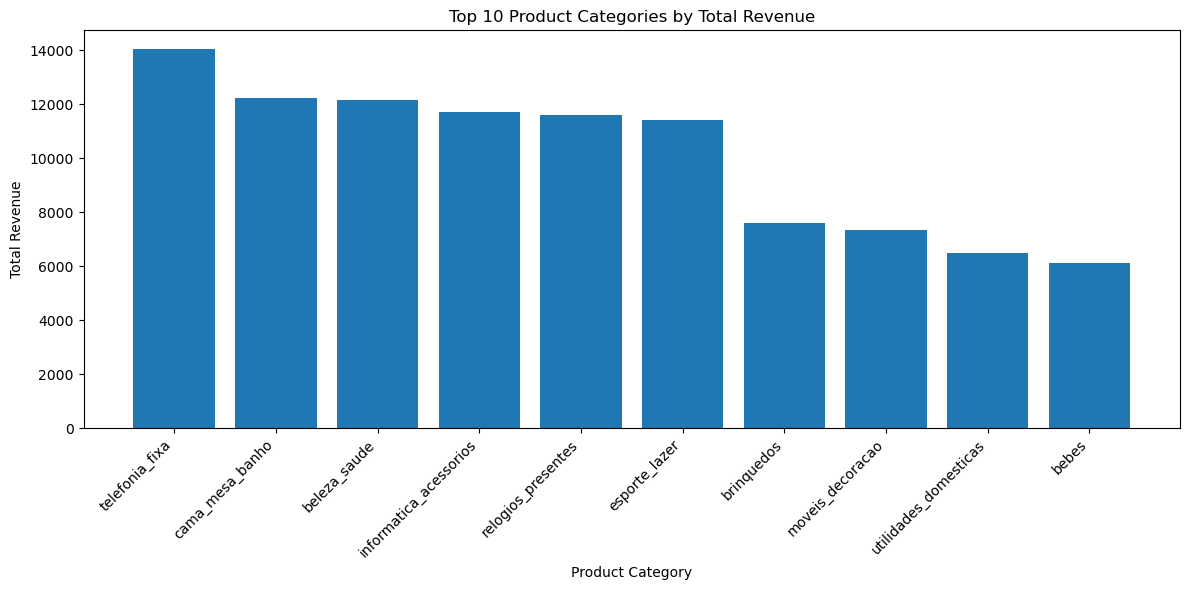

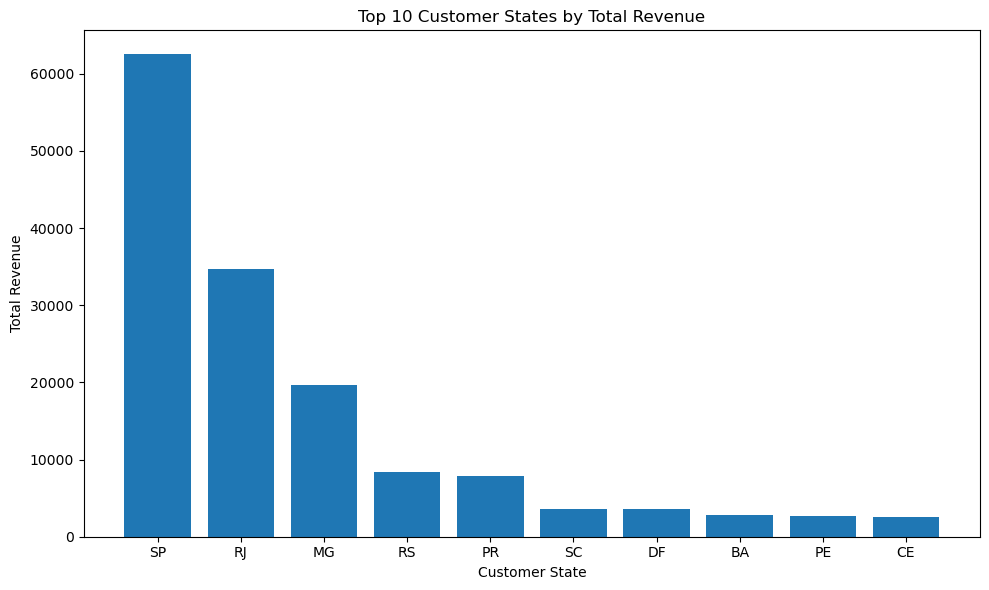

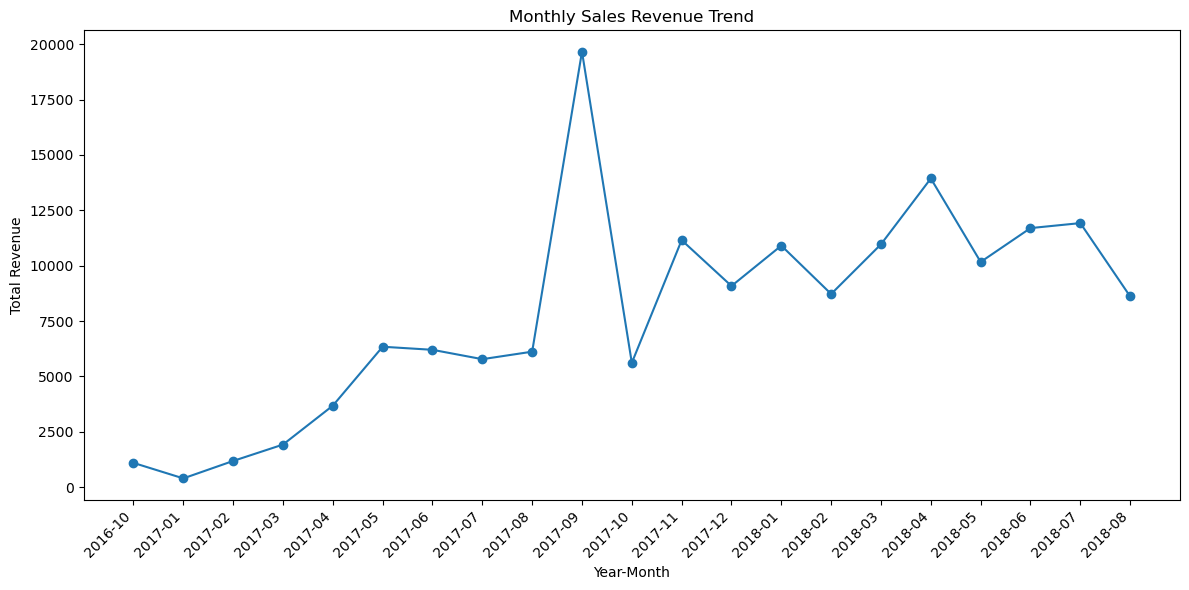

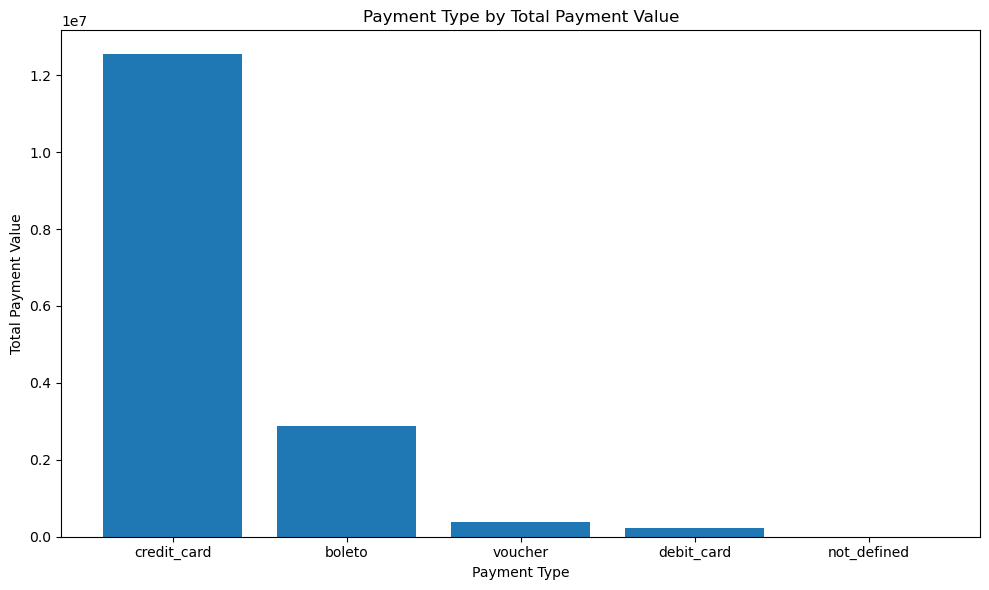

In [39]:
# ============================================================
# Block 16: Optional Visualizations
# ============================================================

import matplotlib.pyplot as plt

spark.sql(f"USE {database_name}")

# ------------------------------------------------------------
# Chart 1: Top 10 Product Categories by Revenue
# ------------------------------------------------------------
df_category_pd = spark.sql("""
SELECT
    product_category_name,
    total_revenue
FROM gold_sales_by_product_category
ORDER BY total_revenue DESC
LIMIT 10
""").toPandas()

plt.figure(figsize=(12, 6))
plt.bar(df_category_pd["product_category_name"], df_category_pd["total_revenue"])
plt.title("Top 10 Product Categories by Total Revenue")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Chart 2: Top 10 Customer States by Revenue
# ------------------------------------------------------------
df_state_pd = spark.sql("""
SELECT
    customer_state,
    total_revenue
FROM gold_sales_by_customer_state
ORDER BY total_revenue DESC
LIMIT 10
""").toPandas()

plt.figure(figsize=(10, 6))
plt.bar(df_state_pd["customer_state"], df_state_pd["total_revenue"])
plt.title("Top 10 Customer States by Total Revenue")
plt.xlabel("Customer State")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Chart 3: Monthly Revenue Trend
# ------------------------------------------------------------
df_monthly_pd = spark.sql("""
SELECT
    year,
    month,
    total_revenue
FROM gold_monthly_sales_trend
ORDER BY year, month
""").toPandas()

df_monthly_pd["year_month"] = (
    df_monthly_pd["year"].astype(str) + "-" + df_monthly_pd["month"].astype(str).str.zfill(2)
)

plt.figure(figsize=(12, 6))
plt.plot(df_monthly_pd["year_month"], df_monthly_pd["total_revenue"], marker="o")
plt.title("Monthly Sales Revenue Trend")
plt.xlabel("Year-Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Chart 4: Payment Type by Total Payment Value
# ------------------------------------------------------------
df_payment_pd = spark.sql("""
SELECT
    payment_type,
    total_payment_value
FROM gold_payment_type_summary
ORDER BY total_payment_value DESC
""").toPandas()

plt.figure(figsize=(10, 6))
plt.bar(df_payment_pd["payment_type"], df_payment_pd["total_payment_value"])
plt.title("Payment Type by Total Payment Value")
plt.xlabel("Payment Type")
plt.ylabel("Total Payment Value")
plt.tight_layout()
plt.show()

## Summary

For this final project, I built a PySpark lakehouse pipeline using Bronze, Silver, and Gold layers. The Bronze layer stores the raw Olist data, the Silver layer cleans and joins the data, and the Gold layer creates business-level summary tables. The main upgrade from the midterm project is that the orders fact data is processed using Structured Streaming and written to Delta format. The final Gold tables summarize revenue by product category, customer state, month, and payment type.